In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

In [2]:
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf', 'png')
plt.rcParams['figure.dpi']=300
plt.rcParams['savefig.dpi']=300

## Linear ODE

In [6]:
def shooting_rhs(x,y):
    '''Function for dy/dx derivatives'''
    return [y[1], 2*x + x*y[0] - x*y[1]]

In [7]:
# target boundary condition
target = 8

In [16]:
# pick a guess for y'(0)
guess1 = 1
sol1 = solve_ivp(shooting_rhs, [0, 2], [1, guess1])
print(f'Solution 1: {sol1.y[0,-1]: .6f}')

Solution 1:  5.999774


In [17]:
# pick a second guess for y'(0)
guess2 = 4
sol2 = solve_ivp(shooting_rhs, [0, 2], [1, guess2])
print(f'Solution 2: {sol2.y[0,-1]: .6f}')

Solution 2:  11.958355


In [19]:
# now use linear interpolation to find a new guess
m = (guess1 - guess2) / (sol1.y[0,-1] - sol2.y[0,-1])
guess3 = guess2 + m * (target - sol2.y[0,-1])
print(f'Guess 3:    {guess3: .6f}')

Guess 3:     2.007065


In [28]:
sol3 = solve_ivp(shooting_rhs, [0, 2], [1, guess3], max_step=0.1)
print(f'Solution 3: {sol3.y[0,-1]: .6f}')
print(f'Target:     {target: .6f}')

Solution 3:  8.000237
Target:      8.000000


In [29]:
sol3.y[0,:]

array([1.        , 1.18731784, 1.3892979 , 1.59393156, 1.8030705 ,
       2.01884416, 2.24361152, 2.47991551, 2.73044276, 2.99799102,
       3.28544576, 3.59576667, 3.93198423, 4.29720595, 4.69463135,
       5.12757471, 5.59949436, 6.11402716, 6.67502736, 7.28660862,
       7.95318868, 8.00023743])

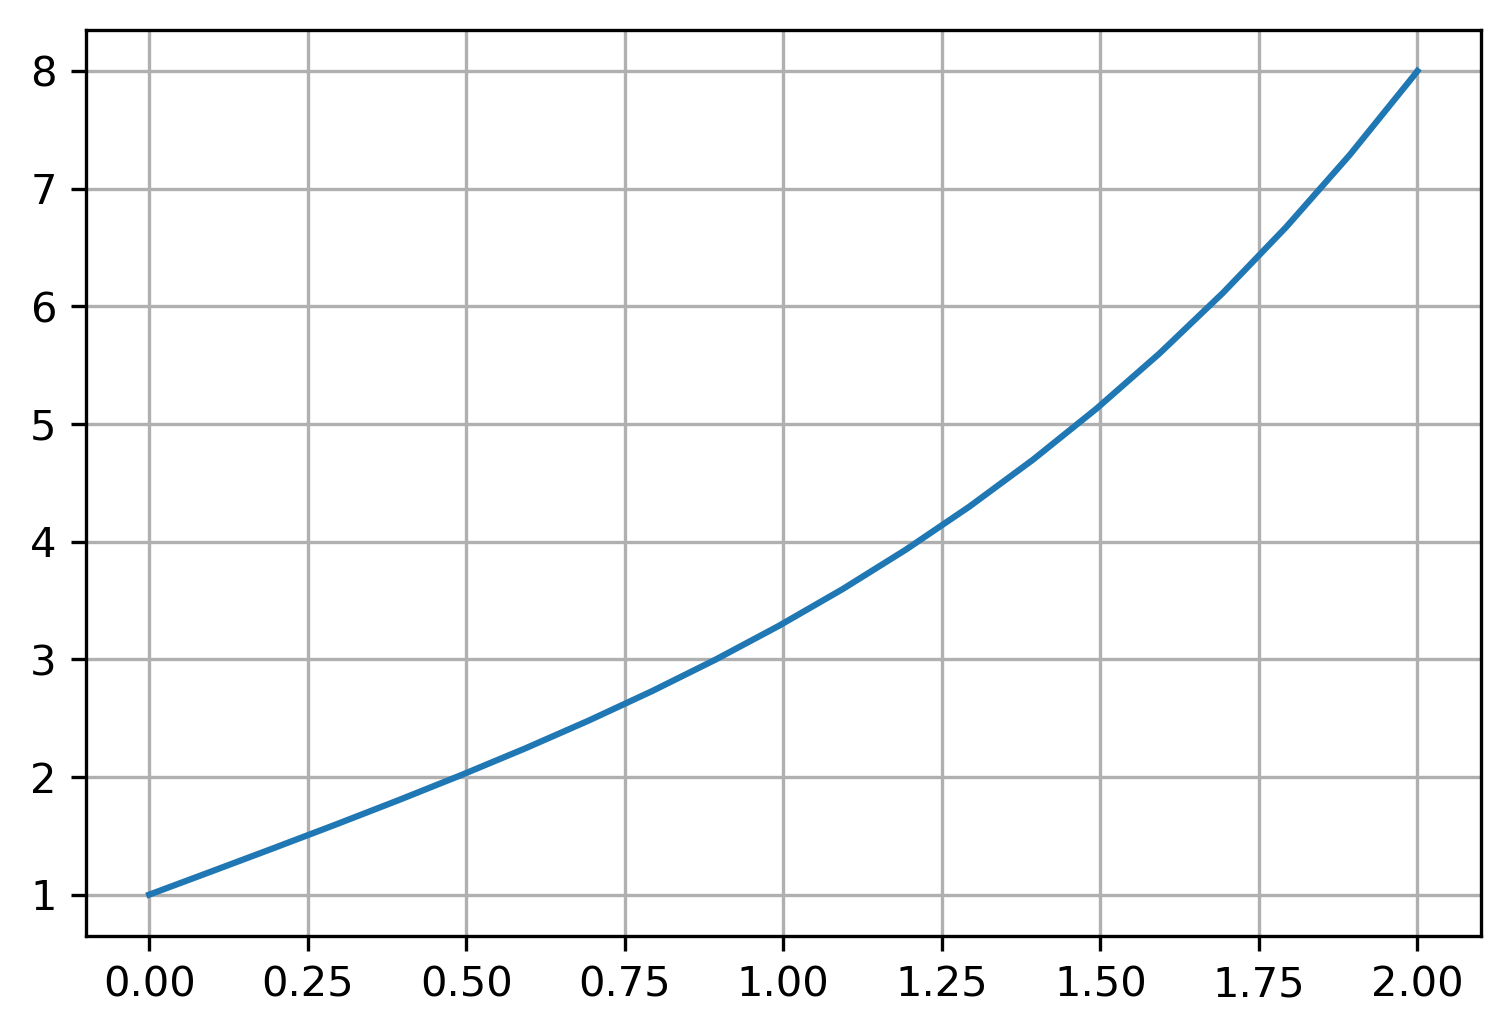

In [23]:
plt.plot(sol3.t, sol3.y[0,:])
plt.grid()
plt.show()

## Nonlinear ODE (Blasius boundary layer)

In [31]:
def blasius_rhs(eta, f):
    '''Derivative function for Blasius problem'''
    return [f[1], f[2], -f[0]*f[2]]

In [32]:
target = 1.0

In [33]:
guesses = []
solutions = []

In [34]:
guesses.append(1)
sol = solve_ivp(blasius_rhs, [0, 10], [0, 0, guesses[0]], max_step= 0.1)
solutions.append(sol.y[1, -1])

In [35]:
guesses.append(0.1)
sol = solve_ivp(blasius_rhs, [0, 10], [0, 0, guesses[1]], max_step=0.1)
solutions.append(sol.y[1,-1])

In [36]:
while np.abs(target - solutions[-1]) > 1e-9:
    m = (guesses[-2] - guesses[-1]) / (solutions[-2] - solutions[-1])
    guesses.append(guesses[-1] + m*(target - solutions[-1]))
    sol = solve_ivp(blasius_rhs, [0, 10], [0, 0, guesses[-1]], max_step=0.1)
    solutions.append(sol.y[1,-1])

    if len(solutions) >= 1e4:
        break 

In [39]:
print('tries guesses solutions')
for idx, (g,s) in enumerate(zip(guesses, solutions)):
    print(f'{idx:3d}   {g:6.4f}  {s:6.4f}')

print(f'Number of iterations required: {len(solutions)}')

tries guesses solutions
  0   1.0000  1.6552
  1   0.1000  0.3566
  2   0.5459  1.1056
  3   0.4830  1.0190
  4   0.4693  0.9995
  5   0.4696  1.0000
  6   0.4696  1.0000
Number of iterations required: 7


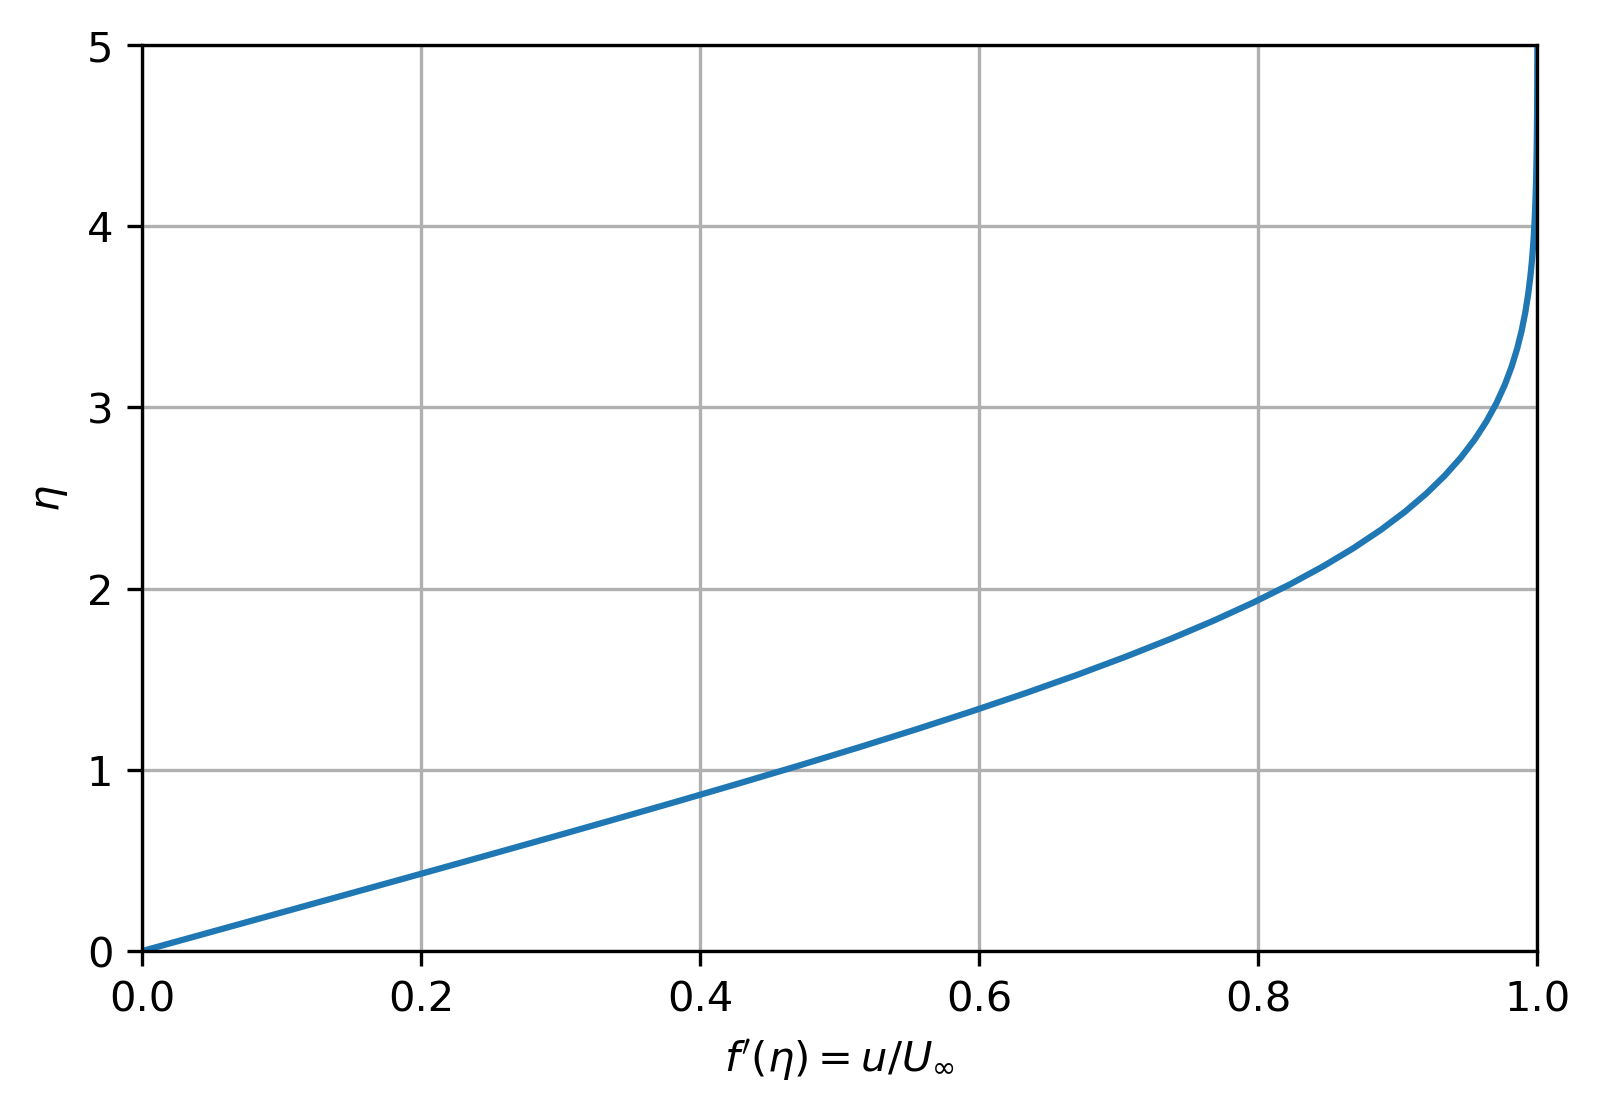

In [40]:
plt.plot(sol.y[1,:], sol.t)
plt.ylabel(r'$\eta$')
plt.xlabel(r'$f^{\prime}(\eta) = u/U_{\infty}$')
plt.ylim([0, 5])
plt.xlim([0, 1])
plt.grid()
plt.show()